# Settings

In [9]:
# Core libraries used throughout this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib as mpl
import plotly.express as px


In [ ]:
# THESIS VISUAL THEME 

# default settings for thesis plots 
THESIS_PALETTE   = "Set2"          
THESIS_FONT      = "Times New Roman"  
THESIS_BG        = "white"
THESIS_GRID_COL  = "#e5e5e5"
THESIS_TITLE_SIZE = 14
THESIS_LABEL_SIZE = 12
THESIS_TICK_SIZE  = 10
THESIS_DPI        = 300            

# Large-figure variants for multi-panel/grid plots (heatmap grids, correlation matrix)
THESIS_TITLE_SIZE_LG = 22
THESIS_LABEL_SIZE_LG = 18
THESIS_TICK_SIZE_LG  = 16
THESIS_ANNOT_SIZE_LG = 18

mpl.rcParams.update({
    # Font
    "font.family":          THESIS_FONT,
    "axes.titlesize":       THESIS_TITLE_SIZE,
    "axes.titleweight":     "bold",
    "axes.labelsize":       THESIS_LABEL_SIZE,
    "xtick.labelsize":      THESIS_TICK_SIZE,
    "ytick.labelsize":      THESIS_TICK_SIZE,
    "legend.fontsize":      THESIS_TICK_SIZE,
    "legend.title_fontsize": THESIS_LABEL_SIZE,

    # Background & grid
    "axes.facecolor":       THESIS_BG,
    "figure.facecolor":     THESIS_BG,
    "axes.grid":            True,
    "grid.color":           THESIS_GRID_COL,
    "grid.linewidth":       0.8,
    "axes.spines.top":      False,     
    "axes.spines.right":    False,

    # Lines & markers
    "lines.linewidth":      2.0,
    "patch.linewidth":      1.2,

    # Figure size & DPI
    "figure.dpi":           100,
    "savefig.dpi":          THESIS_DPI,
    "savefig.bbox":         "tight",
    "savefig.facecolor":    THESIS_BG,
})

sns.set_theme(style="whitegrid", palette=THESIS_PALETTE, rc=mpl.rcParams)

print("✓ Thesis theme loaded.")

✓ Thesis theme loaded.


In [11]:
data = pd.read_csv('data_panel/full_panel_master.csv')
print(data)

    geo nace_r2  real_wage  year  log_wage  ai_adoption  tert_edu  \
0    AT       C      26.74  2021      3.29         9.61      31.8   
1    AT       C      26.07  2023      3.26        12.31      33.5   
2    AT       C      27.12  2025      3.30        32.54      36.2   
3    AT       F      22.43  2021      3.11         3.12      21.2   
4    AT       F      20.32  2023      3.01         4.28      22.5   
..   ..     ...        ...   ...       ...          ...       ...   
703  SK       M      11.53  2023      2.44        12.22      67.6   
704  SK       M      11.73  2025      2.46        28.48      64.8   
705  SK       N       7.35  2021      1.99         8.60      23.2   
706  SK       N       7.21  2023      1.98        10.16      25.0   
707  SK       N       7.37  2025      2.00        19.79      28.0   

     productivity  log_prod    FSI  spec_ict  training_ict  unempl_r  infl_r  \
0          102.25      4.63  55.82     28.74         20.37       6.2     2.8   
1          

# Exploratory Data Analysis

Panel of European countries × NACE Rev. 2 sectors, covering AI adoption, wages, ICT skills, and macroeconomic controls (2021–2024).

**Contents**
1. Data Overview
2. Descriptive Statistics
3. AI Adoption Intensity
4. Multivariate Relationships
5. Outlier Detection
6. Industry-Level Differences
7. Correlation Matrix

## 1. Data Overview

### 1.1 Countries and Industries Covered

In [12]:
# Participating Countries and Sectors
print(f"Total Countries ({data['geo'].unique()})")
print(f"Total NACE Sectors ({data['nace_r2'].unique()})")

Total Countries (['AT' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'ES' 'FI' 'FR' 'HR' 'HU' 'IE'
 'IT' 'LT' 'LU' 'LV' 'MT' 'NL' 'NO' 'PL' 'PT' 'RO' 'SE' 'SI' 'SK'])
Total NACE Sectors (['C' 'F' 'G' 'H' 'I' 'J' 'M' 'N' 'L' 'D' 'E'])


### 1.2 Panel Coverage (Balance Check)

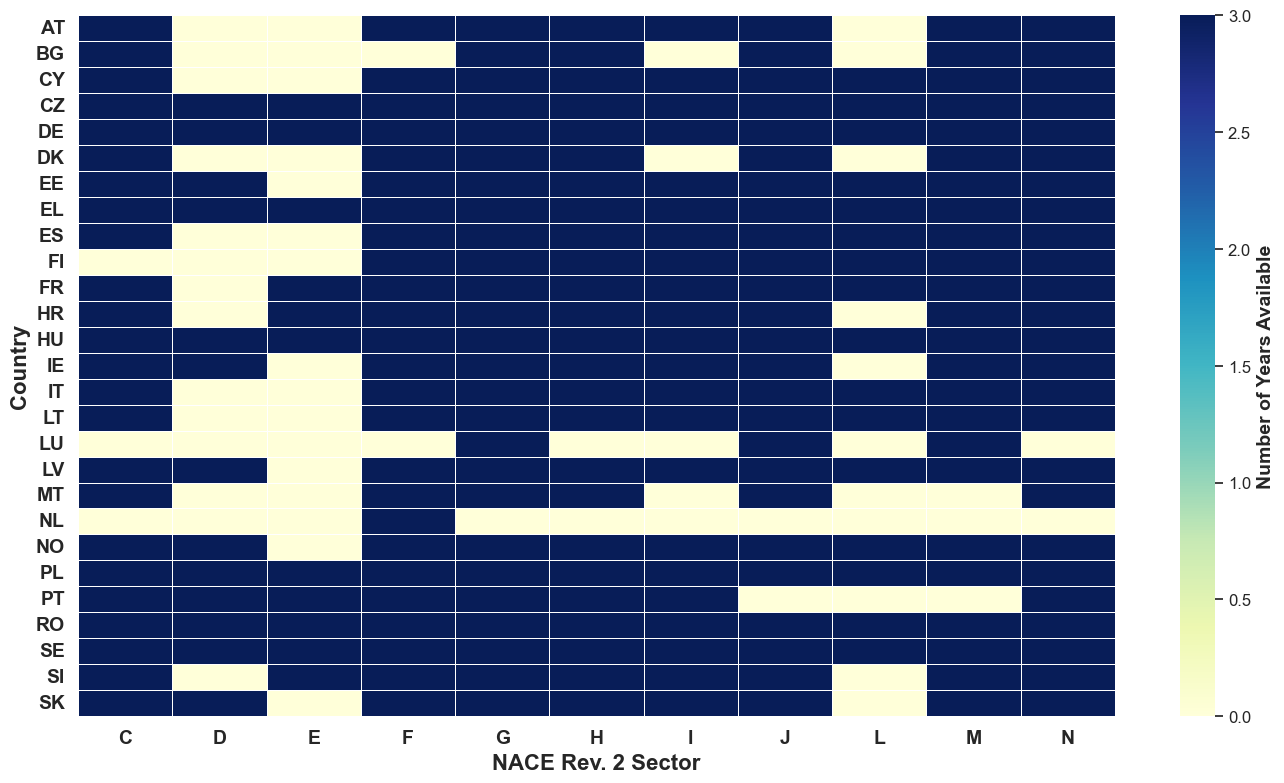

In [ ]:
coverage_table = pd.crosstab(data['geo'], data['nace_r2'])

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    coverage_table,
    annot=False,
    fmt='d',
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Number of Years Available'},
    ax=ax
)

ax.set_ylabel('Country', fontsize=16, fontweight='bold')
ax.set_xlabel('NACE Rev. 2 Sector', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=0, fontweight='bold', fontsize=14)
plt.yticks(rotation=0, fontweight='bold', fontsize=14)
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('Number of Years Available', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('figure1_coverage_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Descriptive Statistics

### 2.1 Variable Heatmaps by Country and Sector

C:\Users\ydmar\AppData\Local\Temp\ipykernel_23776\2125256220.py:64: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



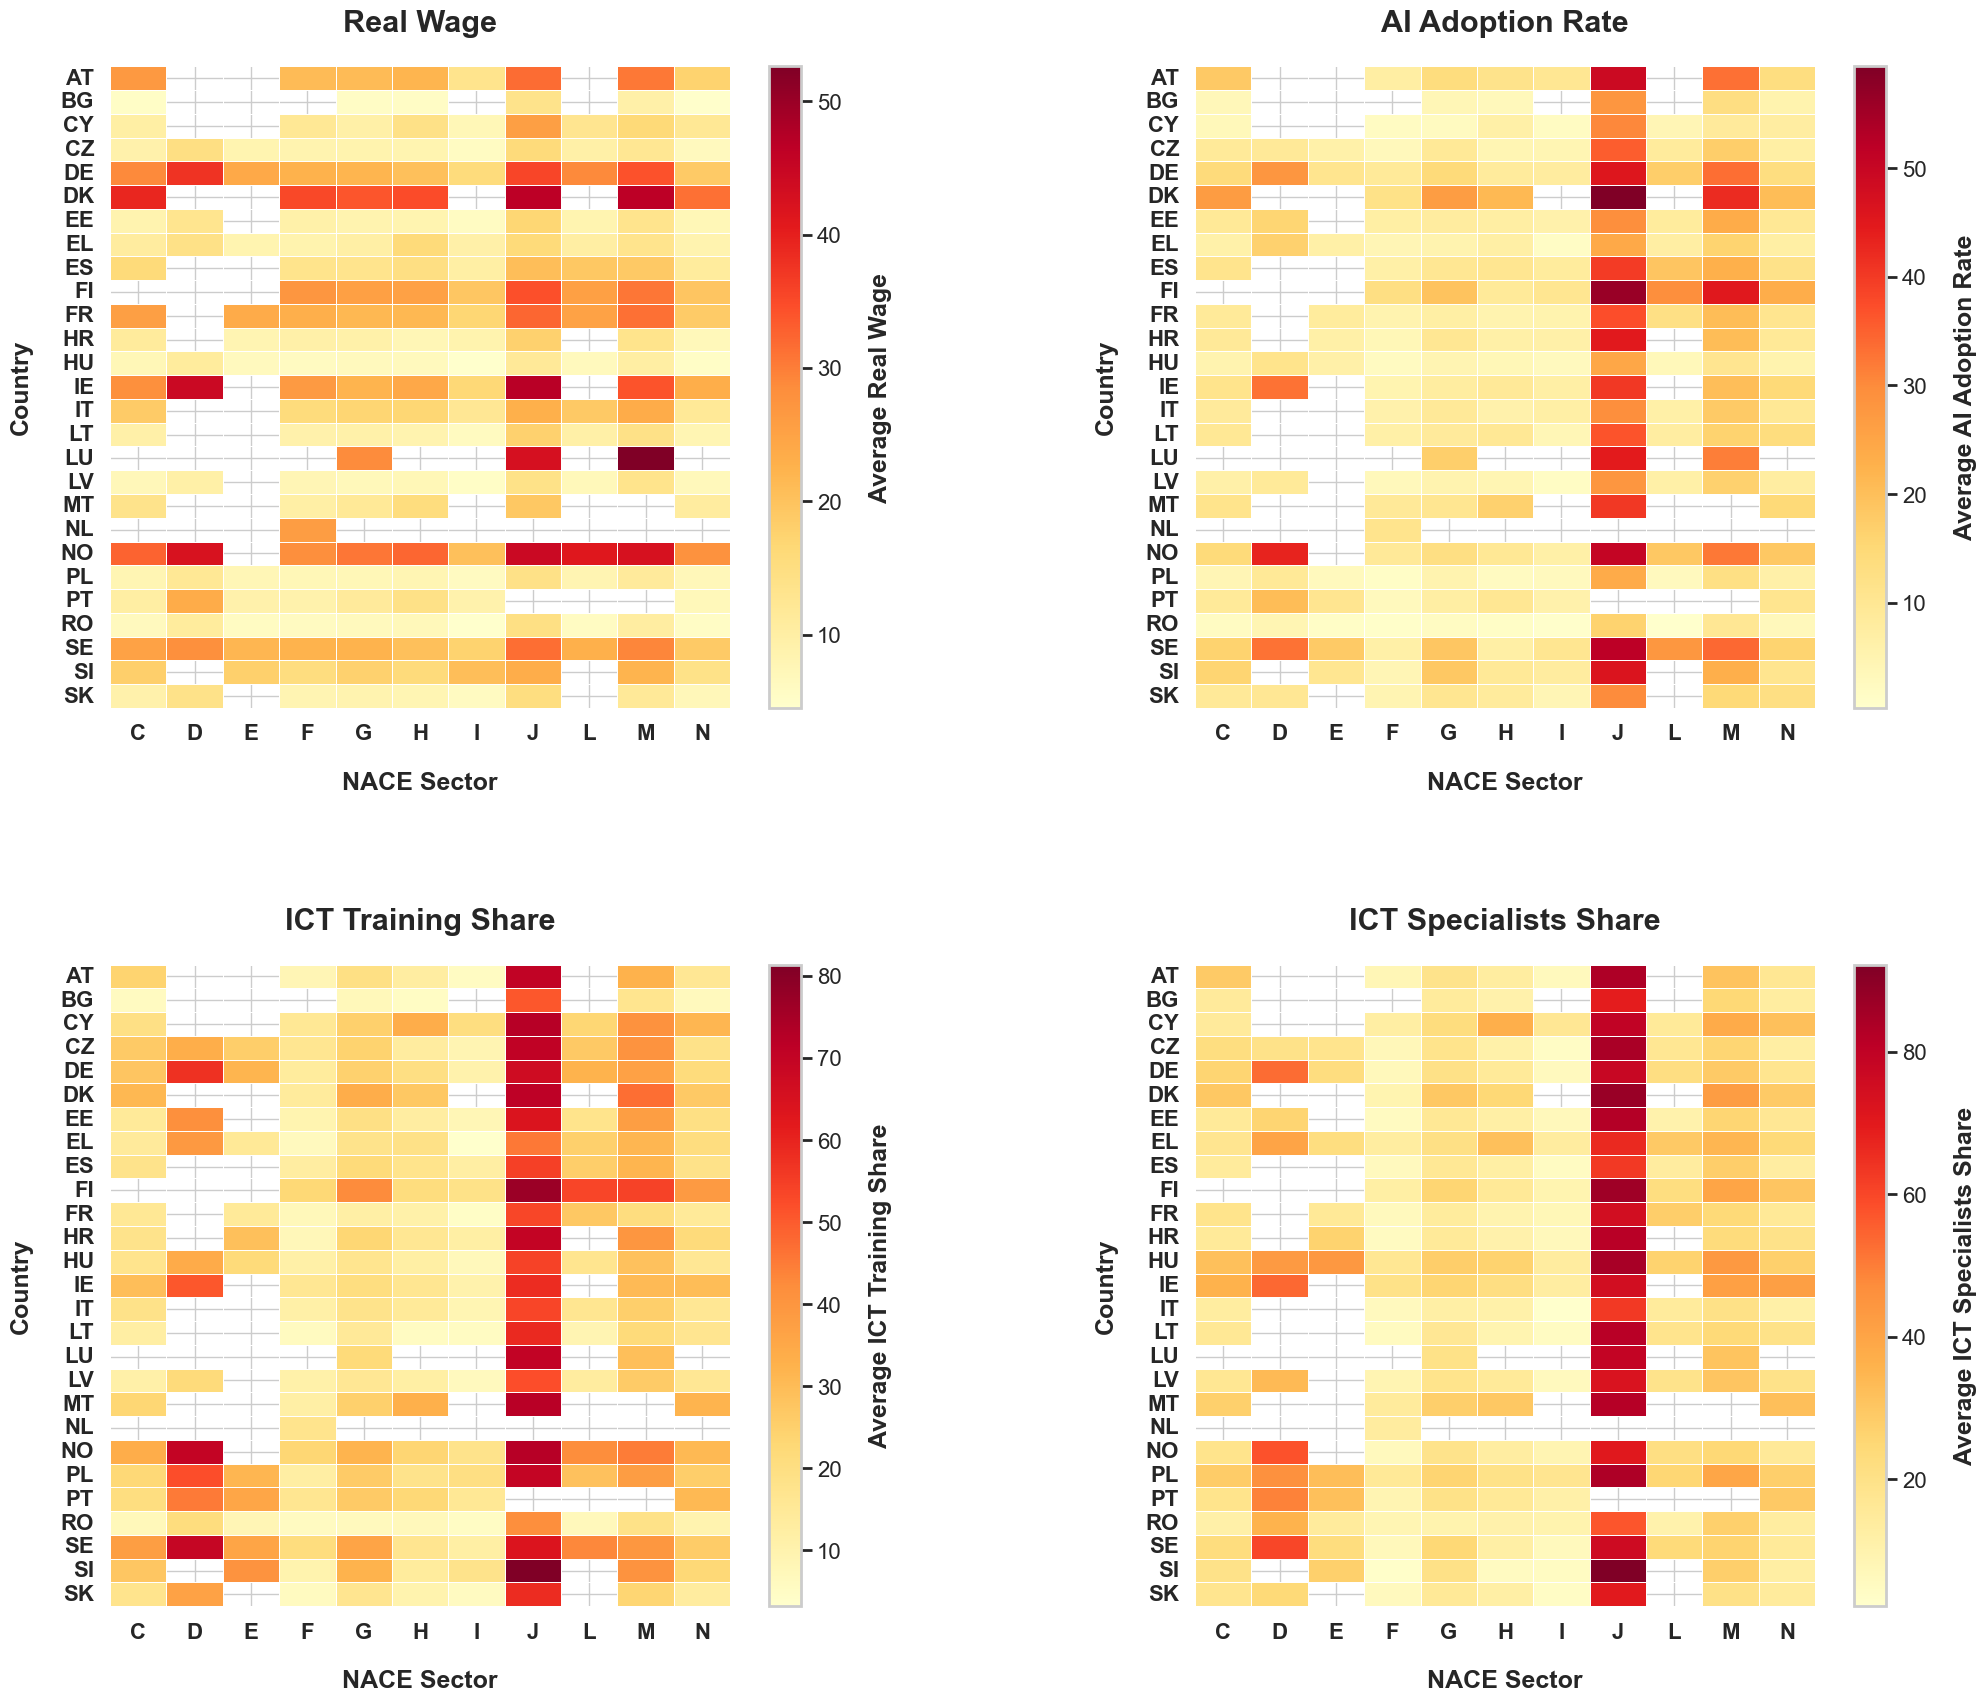

C:\Users\ydmar\AppData\Local\Temp\ipykernel_23776\2125256220.py:64: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



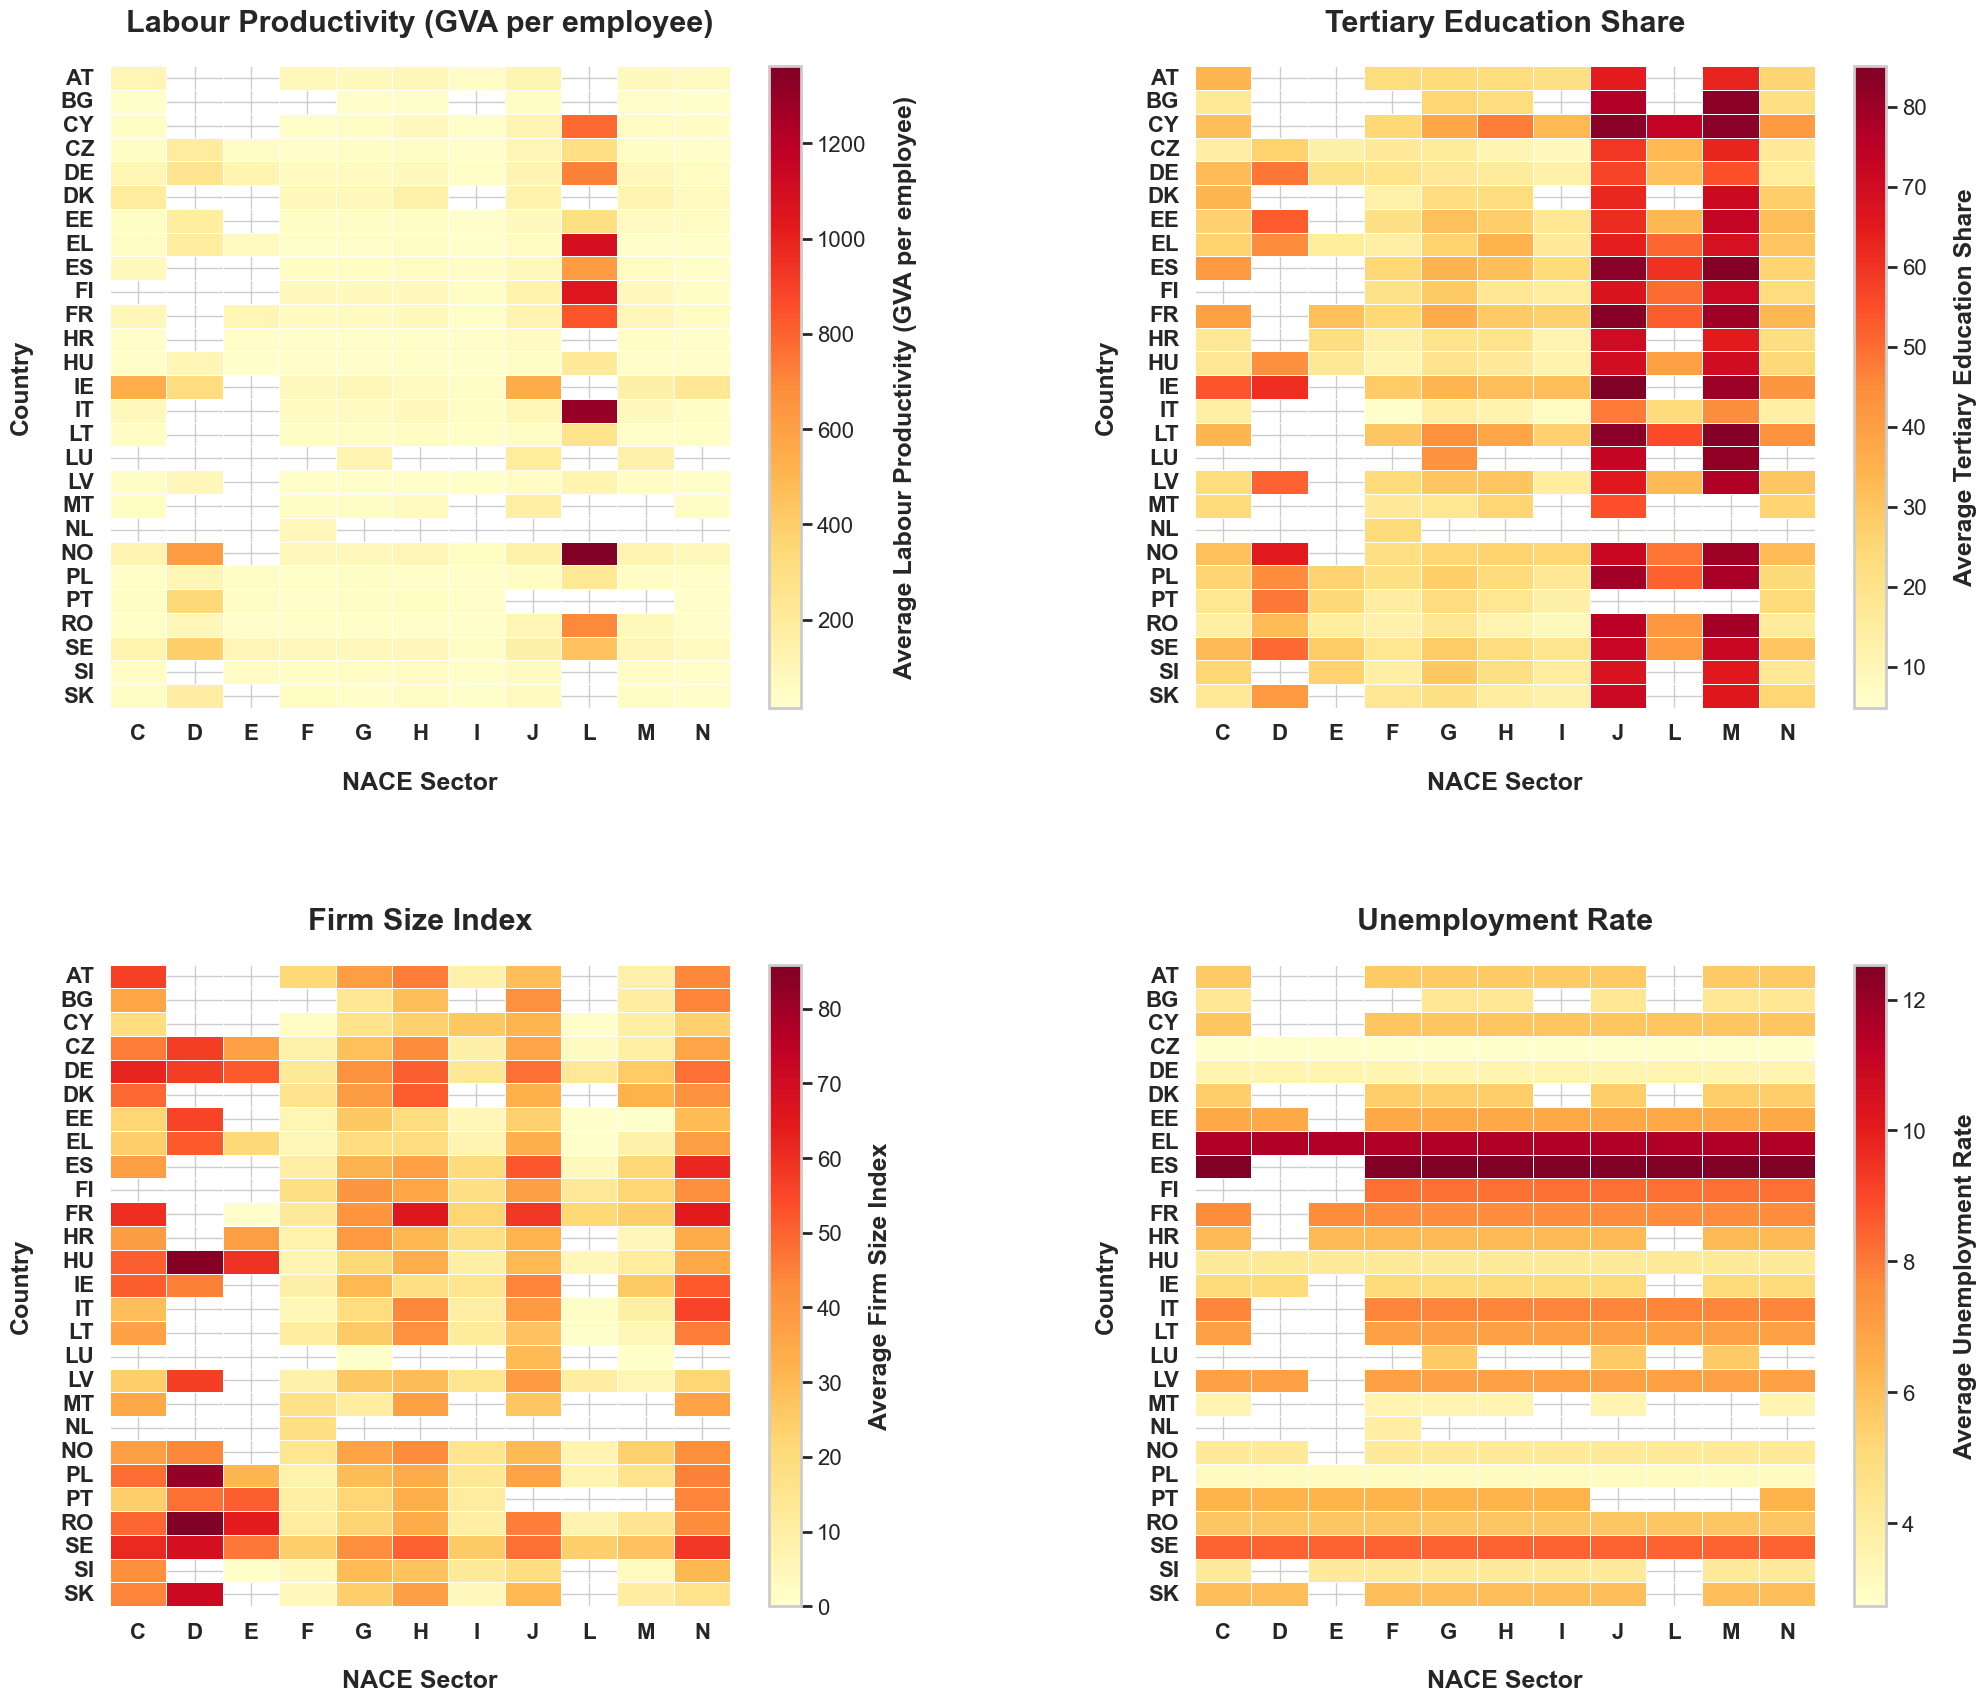

C:\Users\ydmar\AppData\Local\Temp\ipykernel_23776\2125256220.py:64: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



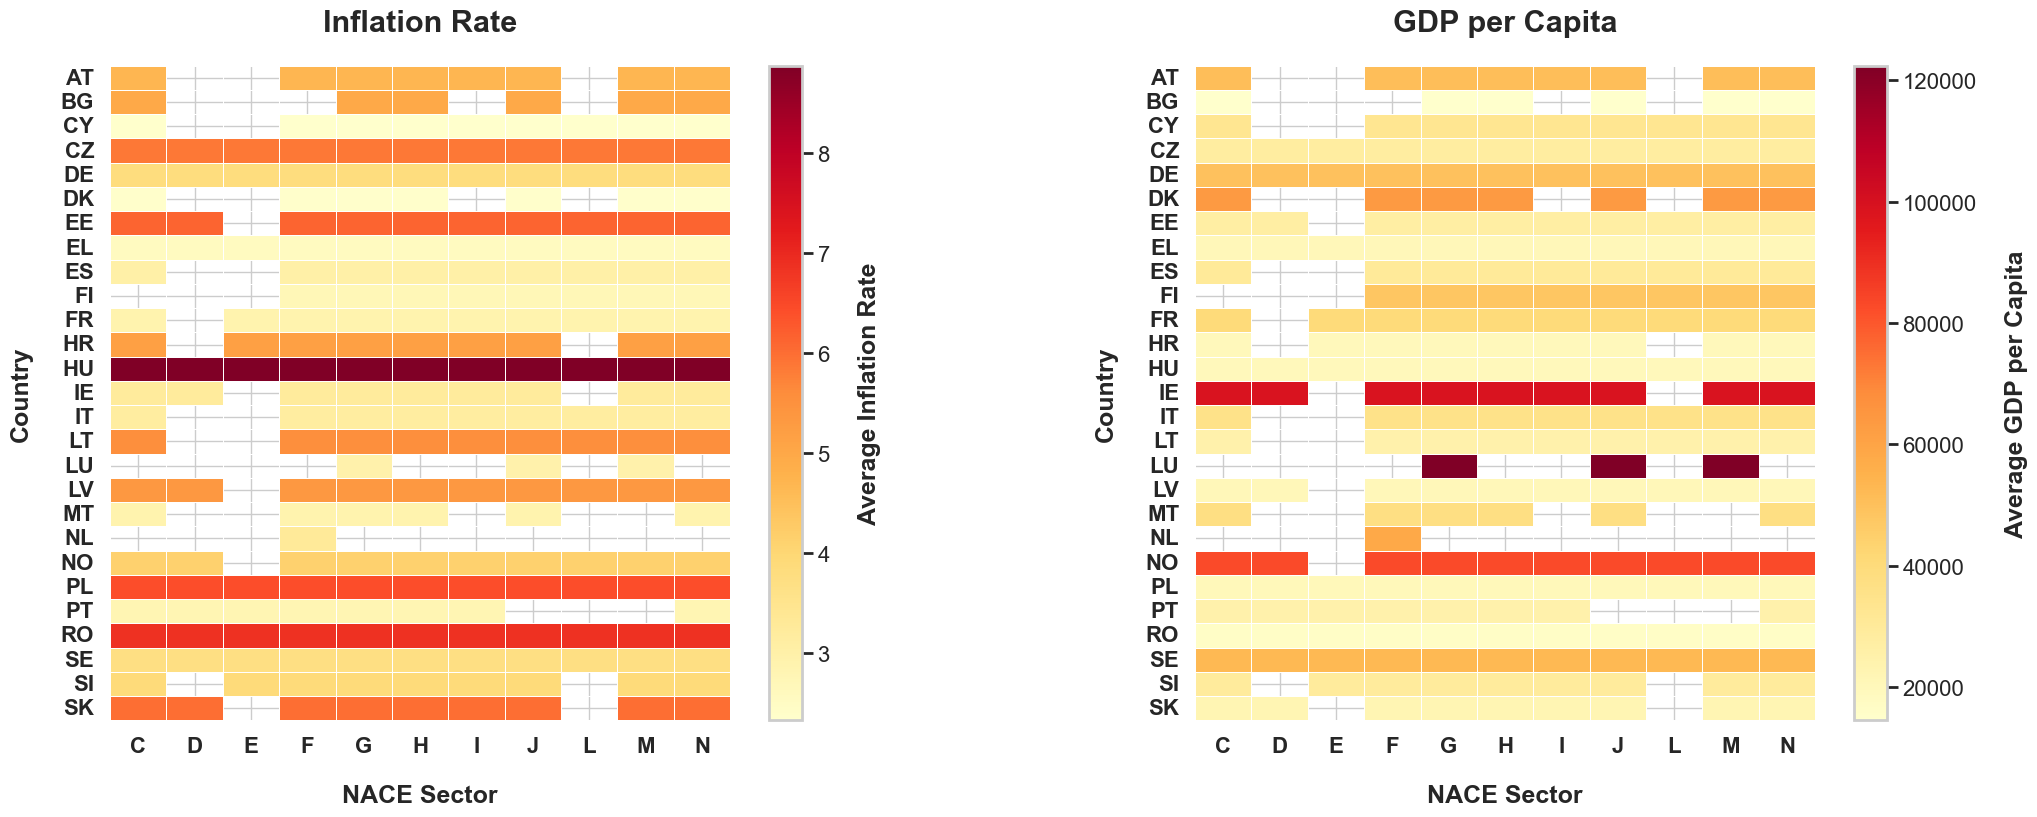

In [14]:
def plot_heatmap_grid_huge(df, vars_dict, ncols=2, max_per_fig=4):
    """
    Plots heatmaps with plain titles (e.g., 'Real Wage') and 
    'Average' prefixed only on the colorbar (right side).
    """
    var_list = list(vars_dict.items())
    
    for chunk_idx in range(0, len(var_list), max_per_fig):
        chunk = dict(var_list[chunk_idx:chunk_idx + max_per_fig])
        n = len(chunk)
        nrows = (n + ncols - 1) // ncols
        
        # Adjust height specifically for 1-row vs 2-row layouts
        if nrows == 2:
            fig_height = 20
        else:
            fig_height = 8.5  
            
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(24, fig_height),
                                 squeeze=False,
                                 gridspec_kw={'wspace': 0.4, 'hspace': 0.4})
        
        for ax, (var, label) in zip(axes.flat, chunk.items()):
            table = df.pivot_table(
                index='geo', 
                columns='nace_r2',
                values=var, 
                aggfunc='mean'
            )
            
            # Title: plain label (no "Average")
            ax.set_title(label, fontsize=THESIS_TITLE_SIZE_LG, fontweight='bold', pad=25)
            
            # Colorbar: with "Average"
            cbar_label = f'Average {label}'
            
            sns.heatmap(
                table,
                annot=False,
                cmap="YlOrRd",
                linewidths=0.6,
                linecolor='white',
                cbar_kws={'label': cbar_label},
                ax=ax
            )
            
            ax.set_ylabel('Country', fontsize=THESIS_LABEL_SIZE_LG, fontweight='bold', labelpad=20)
            ax.set_xlabel('NACE Sector', fontsize=THESIS_LABEL_SIZE_LG, fontweight='bold', labelpad=20)
            ax.tick_params(axis='x', labelsize=THESIS_TICK_SIZE_LG, width=2, length=8)
            ax.tick_params(axis='y', labelsize=THESIS_TICK_SIZE_LG, width=2, length=8, rotation=0)
            
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontweight('bold')
            
            cbar = ax.collections[0].colorbar
            cbar.ax.tick_params(labelsize=THESIS_TICK_SIZE_LG, width=2, length=8)
            cbar.ax.set_ylabel(cbar_label, fontsize=THESIS_LABEL_SIZE_LG, fontweight='bold', labelpad=20)
            cbar.outline.set_linewidth(2)
        
        for ax in axes.flat[n:]:
            ax.set_visible(False)
        
        plt.tight_layout(pad=5.0)
        plt.show()

heat_vars = {
    'real_wage':    'Real Wage',
    'ai_adoption':  'AI Adoption Rate',
    'training_ict': 'ICT Training Share',
    'spec_ict':     'ICT Specialists Share',
    'productivity': 'Labour Productivity (GVA per employee)',
    'tert_edu':     'Tertiary Education Share',
    'FSI':          'Firm Size Index',
    'unempl_r':     'Unemployment Rate',
    'infl_r':       'Inflation Rate',
    'gdp':          'GDP per Capita'
}

plot_heatmap_grid_huge(data, heat_vars, ncols=2, max_per_fig=4)

### 2.2 Panel Summary Statistics (Within/Between Variation)

In [15]:
def panel_summary_statistics(df, variables, geo_col='geo', entity_col='nace_r2'):
    summary_list = []
    
    # variables that are purely macroeconomic (no sector variation)
    macro_vars = ['gdp', 'unempl_r', 'infl_r']

    for var in variables:
        valid_data = df.dropna(subset=[var, geo_col, entity_col])
        NT_valid = len(valid_data)
        
        if NT_valid == 0:
            continue

        overall_mean = valid_data[var].mean()
        overall_min = valid_data[var].min()
        overall_max = valid_data[var].max()
        
        # --- Country dimension ---
        country_means = valid_data.groupby(geo_col)[var].mean()
        N_countries = len(country_means)
        
        between_country_std = np.sqrt(np.sum((country_means - overall_mean)**2) / (N_countries - 1)) if N_countries > 1 else 0.0

        demeaned_country = valid_data[var] - valid_data.groupby(geo_col)[var].transform('mean') + overall_mean
        within_country_std = np.sqrt(np.sum((demeaned_country - overall_mean)**2) / (NT_valid - 1)) if NT_valid > 1 else 0.0

        # --- Sector dimension ---
        # If it's a macro variable, blank out the sector variance since it doesn't apply
        if var in macro_vars:
            between_sector_std = np.nan
            within_sector_std = np.nan
        else:
            sector_means = valid_data.groupby(entity_col)[var].mean()
            N_sectors = len(sector_means)
            
            between_sector_std = np.sqrt(np.sum((sector_means - overall_mean)**2) / (N_sectors - 1)) if N_sectors > 1 else 0.0

            demeaned_sector = valid_data[var] - valid_data.groupby(entity_col)[var].transform('mean') + overall_mean
            within_sector_std = np.sqrt(np.sum((demeaned_sector - overall_mean)**2) / (NT_valid - 1)) if NT_valid > 1 else 0.0

        summary_list.append({
            'Variable': var,
            'Mean': round(overall_mean, 2),
            'Min': round(overall_min, 2),
            'Max': round(overall_max, 2),
            'Between_Country_Std': round(between_country_std, 2) if pd.notna(between_country_std) else '-',
            'Within_Country_Std': round(within_country_std, 2) if pd.notna(within_country_std) else '-',
            'Between_Sector_Std': round(between_sector_std, 2) if pd.notna(between_sector_std) else '-',
            'Within_Sector_Std': round(within_sector_std, 2) if pd.notna(within_sector_std) else '-'
        })

    return pd.DataFrame(summary_list)

all_vars = [
    'real_wage', 'ai_adoption', 'spec_ict', 'training_ict',
    'productivity', 'gdp', 'unempl_r', 'infl_r', 'FSI', 'tert_edu'
]

summary_table = panel_summary_statistics(data, all_vars)
print(summary_table.to_string(index=False))

    Variable     Mean      Min       Max  Between_Country_Std  Within_Country_Std Between_Sector_Std Within_Sector_Std
   real_wage    16.81     4.08     52.91                10.04                4.72               4.42              9.27
 ai_adoption    13.82     0.00     87.87                 6.93               13.23               9.51              11.1
    spec_ict    26.15     1.58     98.25                 6.87               19.89              19.15              7.66
training_ict    26.40     2.00     84.70                 8.01               16.11              15.16              9.57
productivity   117.64    11.98   1408.81                64.17              194.67              195.7            125.03
         gdp 37376.61 10960.00 130300.00             26466.33             3669.27                  -                 -
    unempl_r     6.13     2.60     14.90                 2.35                0.86                  -                 -
      infl_r     4.47     0.60     17.00        

### 2.3 Variable Distributions

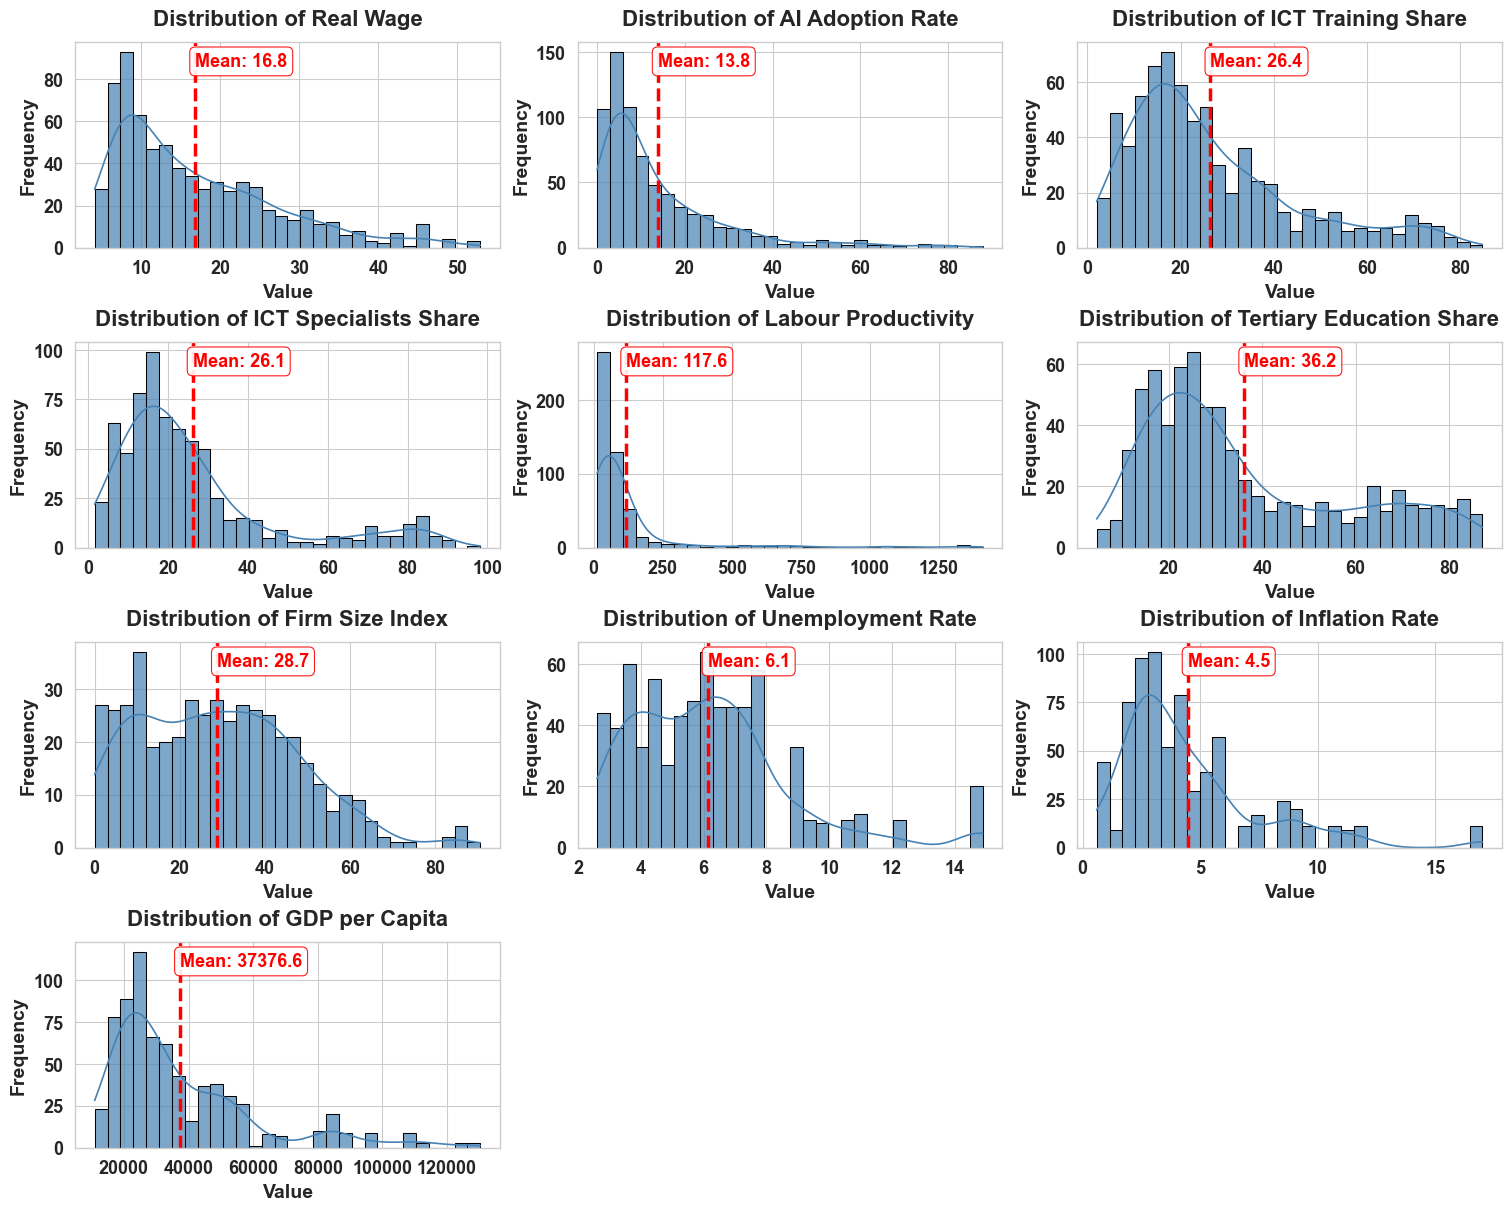

In [ ]:
def plot_all_distributions(df, label_map):
    vars_to_plot = [var for var in label_map.keys() if var in df.columns]

    n_vars = len(vars_to_plot)
    cols = 3
    rows = int(np.ceil(n_vars / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12),
                             constrained_layout=True)
    axes = axes.flatten()
    
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        label = label_map[var]
        
        sns.histplot(df[var].dropna(), kde=True, bins=30, color='steelblue',
                     edgecolor='black', alpha=0.7, ax=ax)
        
        ax.set_title(f'Distribution of {label}', fontsize=16, fontweight='bold', pad=12)
        ax.set_xlabel('Value', fontsize=14, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
        ax.tick_params(axis='both', labelsize=13, width=1.5, length=5)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')
        mean_val = df[var].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2.5)
        ax.text(mean_val, 0.95, f'Mean: {mean_val:.1f}', 
                transform=ax.get_xaxis_transform(),  
                color='red', fontsize=13, fontweight='bold',
                ha='left', va='top', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='red', alpha=0.9))
    
    for j in range(len(vars_to_plot), len(axes)):
        fig.delaxes(axes[j])
    
    plt.show()

var_labels = {
    'real_wage':    'Real Wage',
    'ai_adoption':  'AI Adoption Rate',
    'training_ict': 'ICT Training Share',
    'spec_ict':     'ICT Specialists Share',
    'productivity': 'Labour Productivity',
    'tert_edu':     'Tertiary Education Share',
    'FSI':          'Firm Size Index',
    'unempl_r':     'Unemployment Rate',
    'infl_r':       'Inflation Rate',
    'gdp':          'GDP per Capita'
}

plot_all_distributions(data, var_labels)

## 3. AI Adoption Intensity

**AI Intensity Index.** For each country, the AI adoption share is averaged across sectors and over the 2021–2024 period, yielding a single country-level indicator. This value is then rescaled relative to the mean across all sample countries, which is set to 100. A country with an index above (below) 100 therefore exhibits above- (below-) average AI adoption intensity relative to the panel of European countries covered in this study.

In [ ]:
def create_ai_intensity_map_period_avg(df):
    df_period = df[df['year'].between(2021, 2025)].copy()

    # 1) Average across industries within each country-year
    country_year = (
        df_period
        .groupby(['geo', 'year'], as_index=False)['ai_adoption']
        .mean()
    )

    # 2) Average across years within each country
    country_avg = (
        country_year
        .groupby('geo', as_index=False)['ai_adoption']
        .mean()
        .rename(columns={'ai_adoption': 'ai_period_avg'})
    )

    # 3) Sample average of country period averages (covers EU + non-EU countries, e.g. Norway)
    sample_average = country_avg['ai_period_avg'].mean()

    # 4) Build index: sample average = 100
    country_avg['AI_Intensity_Index'] = (country_avg['ai_period_avg'] / sample_average) * 100

    # Eurostat 2-letter codes -> ISO-3
    iso2_to_iso3 = {
        'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CY': 'CYP', 'CZ': 'CZE',
        'DE': 'DEU', 'DK': 'DNK', 'EE': 'EST', 'ES': 'ESP', 'FI': 'FIN',
        'FR': 'FRA', 'HR': 'HRV', 'HU': 'HUN', 'IE': 'IRL', 'IT': 'ITA',
        'LT': 'LTU', 'LV': 'LVA', 'MT': 'MLT', 'NL': 'NLD', 'NO': 'NOR',
        'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 'SE': 'SWE', 'SI': 'SVN',
        'SK': 'SVK'
    }

    country_avg['iso3'] = country_avg['geo'].map(iso2_to_iso3)
    country_avg = country_avg.dropna(subset=['iso3'])

    # 5) Choropleth
    fig = px.choropleth(
        country_avg,
        locations='iso3',
        color='AI_Intensity_Index',
        hover_name='geo',
        hover_data={
            'iso3': False,
            'ai_period_avg': ':.2f',
            'AI_Intensity_Index': ':.1f'
        },
        scope='europe',
        color_continuous_scale='Blues',
        labels={
            'AI_Intensity_Index': 'AI Intensity Index',
            'ai_period_avg': 'AI share (2021–2025 avg)'
        }
    )

    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular',
            showland=True,           
            landcolor='lightgray',   
            countrycolor='white'     
        ),

        coloraxis_colorbar=dict(
            title=dict(
                text='Index<br>(Sample avg=100)',
                font=dict(size=13, weight='bold')
            ),
            tickvals=[50, 75, 100, 125, 150],
            ticktext=['50', '75', '100', '125', '150'],
            tickfont=dict(size=11, weight='bold'),
            len=0.6,                               
            thickness=15,                          
            x=1.02,                                
            y=0.5                                 
        )
    )

    fig.update_layout(
        width=900,
        height=650,
        margin=dict(l=0, r=0, t=30, b=0)
    )

    fig.show()

    return country_avg

country_map_data = create_ai_intensity_map_period_avg(data)

## 4. Multivariate Relationships

### 4.1 AI Adoption, Real Wages, and ICT Skills

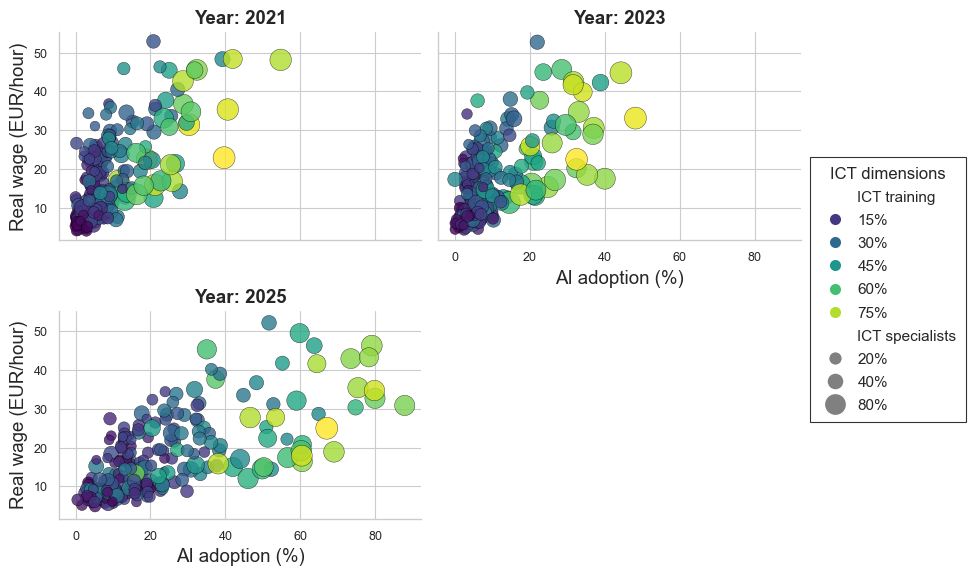

In [ ]:
def plot_4d_bubble_facets(df, filename=None):
    sns.set_theme(style="whitegrid", context="paper")
    sns.set_context("paper", font_scale=1.4)

    g = sns.FacetGrid(
        df,
        col="year",
        col_wrap=2,
        height=3.0,
        aspect=1.6
    )

    g.map_dataframe(
        sns.scatterplot,
        x="ai_adoption",
        y="real_wage",
        hue="training_ict",
        size="spec_ict",
        sizes=(40, 250),
        palette="viridis",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.3,
        legend=False
    )

    g.set_axis_labels("AI adoption (%)", "Real wage (EUR/hour)")
    g.set_titles("Year: {col_name}")

    for ax in g.axes.flat:
        ax.tick_params(labelsize=9)

    ax = g.axes.flat[-1]
    cmap = plt.cm.viridis
    training_min, training_max = df['training_ict'].min(), df['training_ict'].max()
    training_levels = [15, 30, 45, 60, 75]

    training_norm = plt.Normalize(training_min, training_max)
    color_handles = [
        mlines.Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(training_norm(v)),
            markersize=9,         
            label=f"{v:.0f}%"
        )
        for v in training_levels
    ]

    spec_min, spec_max = df['spec_ict'].min(), df['spec_ict'].max()
    spec_levels = [20, 40, 80]
    size_min, size_max = 40, 250

    size_handles = [
        mlines.Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor='grey',
            markersize=np.sqrt(size_min + (v - spec_min) / (spec_max - spec_min) * (size_max - size_min)) * 1.1,  # 10% bigger
            label=f"{v:.0f}%"
        )
        for v in spec_levels
    ]

    training_title = mpatches.Patch(color='none', label='ICT training')
    spec_title = mpatches.Patch(color='none', label='ICT specialists')

    all_handles = [training_title] + color_handles + [spec_title] + size_handles

    g.figure.subplots_adjust(right=0.85)  
    
    g.figure.legend(
        handles=all_handles,
        title="ICT dimensions",
        loc='center right',
        bbox_to_anchor=(1.03, 0.50),  
        frameon=True,
        fontsize=11,                  
        title_fontsize=12,            
        labelspacing=0.6,            
        handletextpad=0.5,            
        borderpad=0.6,              
        edgecolor='black',
        fancybox=False
    )

    if filename is not None:
        g.savefig(filename, dpi=300)
    plt.show()


plot_4d_bubble_facets(data, filename="figure6_ai_wage_ict_facets.png")

### 4.2 Pairwise Correlations by Industry

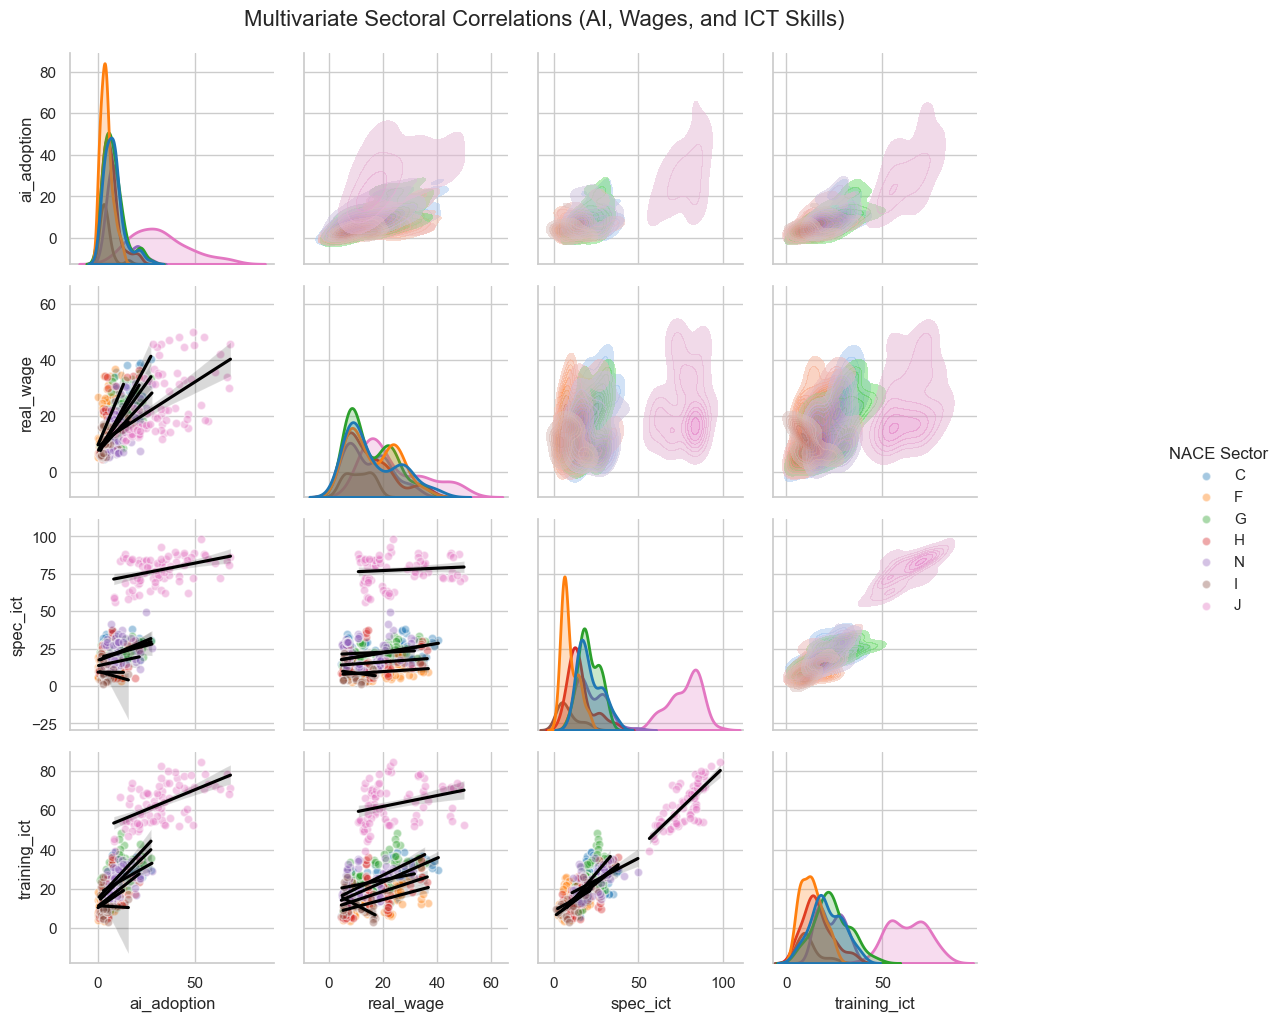

In [ ]:
def plot_advanced_pairgrid(df):
    # Select only the variables  to correlate
    vars_to_plot = ['ai_adoption', 'real_wage', 'spec_ict', 'training_ict']
    
    # Create the PairGrid, colored by Industry
    g = sns.PairGrid(df, vars=vars_to_plot, hue="nace_r2", palette="tab10", corner=False)
    
    # 1. Upper Triangle: 2D Density Contours (shows clustering of country-sectors)
    g.map_upper(sns.kdeplot, fill=True, alpha=0.5)
    
    # 2. Lower Triangle: Scatter with Regression Line (shows the trend)
    g.map_lower(sns.regplot, scatter_kws={'alpha':0.4, 'edgecolor':'w'}, line_kws={'color':'black'})
    
    # 3. Diagonal: Density distribution of the variable itself
    g.map_diag(sns.kdeplot, lw=2, fill=True)
    
    g.add_legend(title="NACE Sector", bbox_to_anchor=(1.05, 0.5), loc='center left')
    g.figure.suptitle("Multivariate Sectoral Correlations (AI, Wages, and ICT Skills)", y=1.02, fontsize=16)
    
    plt.show()
plot_advanced_pairgrid(data)


## 5. Outlier Detection

In [ ]:
def detect_panel_outliers(df, variables):
    all_outliers = pd.DataFrame()
    
    for var in variables:
        # Group by Industry and Year
        for _, group in df.groupby(['nace_r2', 'year']):
            # Skip if there's not enough data to calculate quartiles
            if len(group) < 4:
                continue
                
            Q1 = group[var].quantile(0.25)
            Q3 = group[var].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define bounds 
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter rows that fall outside the bounds
            outliers = group[(group[var] < lower_bound) | (group[var] > upper_bound)].copy()
            
            if not outliers.empty:
                outliers['Variable'] = var
                outliers['Value'] = outliers[var].round(2)
                outliers['Outlier_Type'] = outliers[var].apply(lambda x: 'High' if x > upper_bound else 'Low')
                outliers['Normal_Max'] = round(upper_bound, 2)
                outliers['Normal_Min'] = round(lower_bound, 2)
                
                # Keep only the identifying information
                outliers_clean = outliers[['geo', 'nace_r2', 'year', 'Variable', 'Value', 
                                           'Outlier_Type', 'Normal_Min', 'Normal_Max']]
                
                all_outliers = pd.concat([all_outliers, outliers_clean], ignore_index=True)
                
    return all_outliers

core_vars = ['ai_adoption', 'real_wage', 'spec_ict', 'training_ict']
exact_outliers_df = detect_panel_outliers(data, core_vars)
print("--- Exact Outliers Identified ---")
exact_outliers_df = exact_outliers_df.sort_values(by=['Variable', 'year', 'nace_r2'])
print(exact_outliers_df.to_string(index=False))


--- Exact Outliers Identified ---
geo nace_r2  year     Variable  Value Outlier_Type  Normal_Min  Normal_Max
 DK       C  2021  ai_adoption  27.28         High       -3.96       16.52
 DK       G  2021  ai_adoption  21.30         High       -5.02       15.99
 DK       H  2021  ai_adoption  21.28         High       -2.36       12.84
 MT       H  2021  ai_adoption  15.00         High       -2.36       12.84
 DK       J  2021  ai_adoption  54.75         High       -4.53       51.15
 DK       M  2021  ai_adoption  39.22         High      -11.00       37.23
 DK       N  2021  ai_adoption  19.04         High       -2.94       15.58
 FI       N  2021  ai_adoption  17.28         High       -2.94       15.58
 MT       F  2023  ai_adoption   9.05         High       -1.20        7.57
 DK       H  2023  ai_adoption  15.16         High       -2.62       13.58
 MT       H  2023  ai_adoption  16.45         High       -2.62       13.58
 FI       L  2023  ai_adoption  18.80         High       -5.82    

In [ ]:
def summarize_outliers(outliers_df):
    print("\n--- Outlier Count by Country ---")
    country_counts = outliers_df['geo'].value_counts()
    print(country_counts[country_counts > 0])
    
    print("\n--- Outlier Count by Industry ---")
    industry_counts = outliers_df['nace_r2'].value_counts()
    print(industry_counts[industry_counts > 0])
    
    print("\n--- Outlier Count by Variable ---")
    var_counts = outliers_df['Variable'].value_counts()
    print(var_counts)
summarize_outliers(exact_outliers_df)



--- Outlier Count by Country ---
geo
DK    14
CY     7
PL     5
HU     4
IE     2
FI     2
FR     2
NO     1
BE     1
SE     1
Name: count, dtype: int64

--- Outlier Count by Industry ---
nace_r2
H    19
I     8
G     5
N     3
C     2
J     1
F     1
Name: count, dtype: int64

--- Outlier Count by Variable ---
Variable
spec_ict        15
ai_adoption     12
training_ict    12
Name: count, dtype: int64


## 6. Industry-Level Differences

### 6.1 AI Adoption by Industry


--- Average Values by Industry (All Years) ---
         real_wage  ai_adoption  spec_ict
nace_r2                                  
J            25.02        37.74     77.03
M            22.78        22.37     30.16
D            21.21        18.74     41.75
N            12.71        11.39     21.03
L            16.28        11.25     19.91
G            15.29        10.37     20.04
C            16.11        10.17     20.86
E            12.85         7.99     25.39
H            15.37         7.96     16.44
F            15.54         5.91      9.44
I            11.02         5.66      8.46


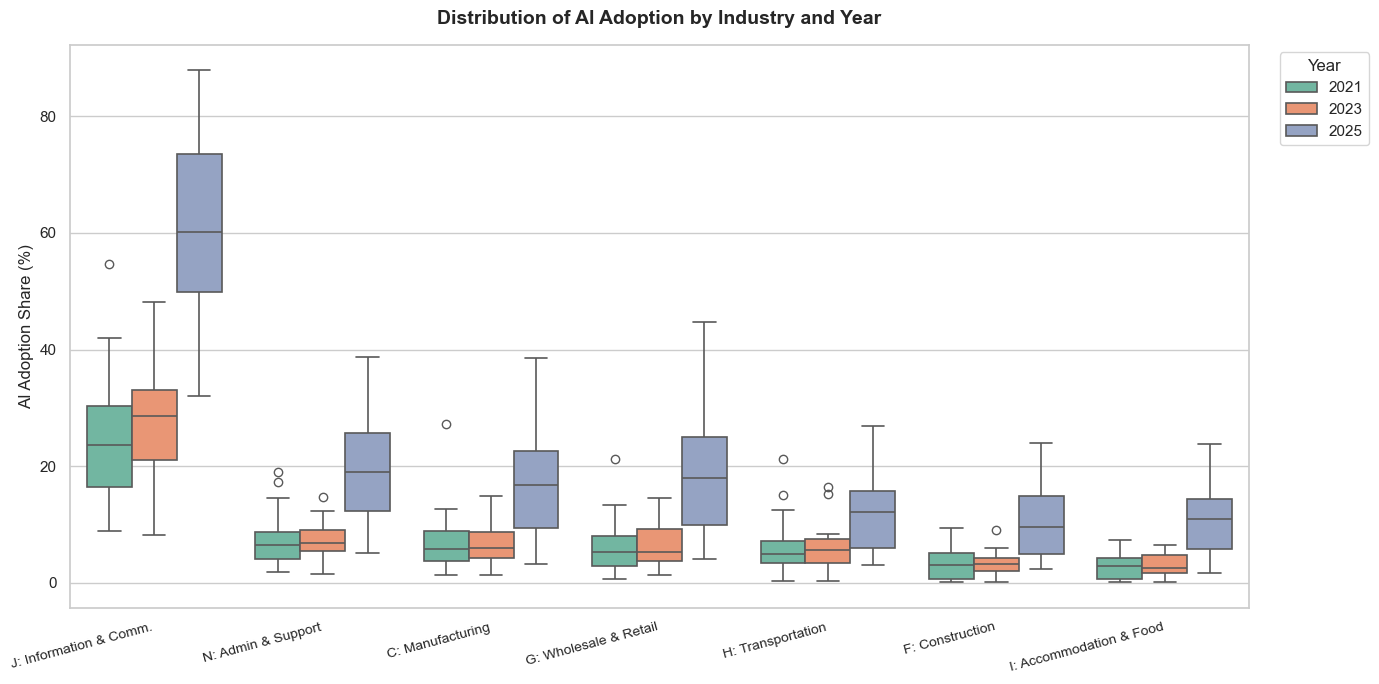

In [16]:
def analyze_industry_differences(df):
    nace_labels = {
        'C': 'C: Manufacturing',
        'F': 'F: Construction',
        'G': 'G: Wholesale & Retail',
        'H': 'H: Transportation',
        'I': 'I: Accommodation & Food',
        'J': 'J: Information & Comm.',
        'N': 'N: Admin & Support'
    }
    
    df_plot = df.copy()
    df_plot['industry_name'] = df_plot['nace_r2'].map(nace_labels)

    # Summary statistics for industries over the whole period
    industry_summary = df.groupby('nace_r2')[['real_wage', 'ai_adoption', 'spec_ict']].mean().round(2)
    print("\n--- Average Values by Industry (All Years) ---")
    print(industry_summary.sort_values(by='ai_adoption', ascending=False))
    

    plt.figure(figsize=(14, 7)) 
    order = df_plot.groupby('industry_name')['ai_adoption'].median().sort_values(ascending=False).index
    
    ax = sns.boxplot(
        data=df_plot, 
        x='industry_name', 
        y='ai_adoption', 
        hue='year', 
        order=order, 
        palette='Set2',
        linewidth=1.2
    )
    ax.set_title('Distribution of AI Adoption by Industry and Year', fontsize=14, pad=15)
    ax.set_ylabel('AI Adoption Share (%)', fontsize=12)
    ax.set_xlabel('')
    plt.xticks(rotation=15, ha='right', fontsize=10)
    plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.tight_layout()
    plt.savefig('ai_adoption_by_industry.png', dpi=300, bbox_inches='tight')
    plt.show()

analyze_industry_differences(data)

### 6.2 Core Variables by Industry

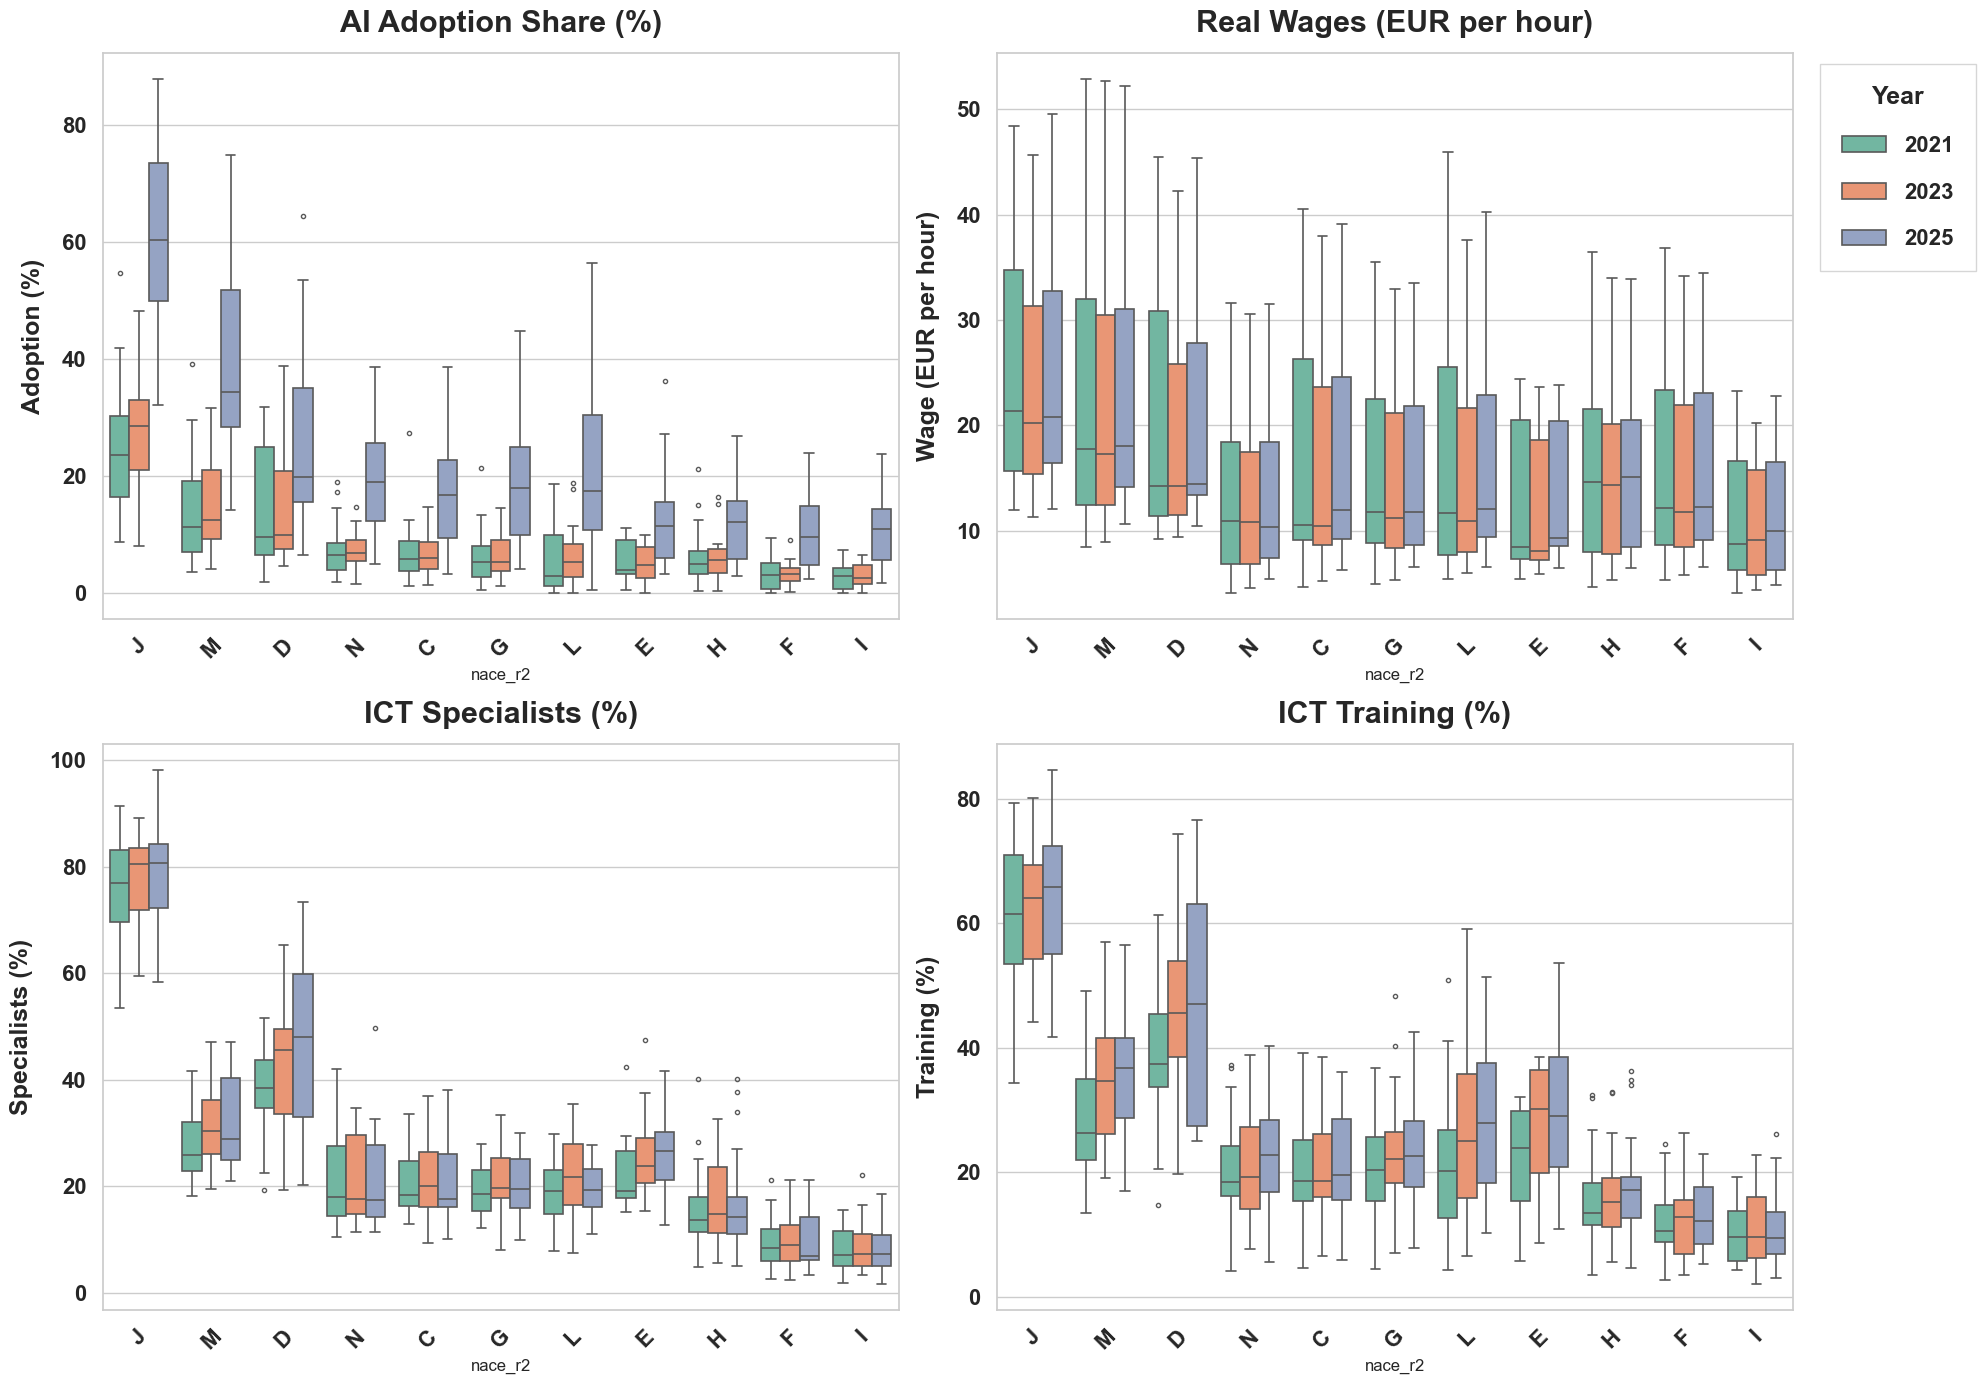

In [21]:
def plot_core_variables_grid(df):
    df_plot = df.copy()
    
    variables = [
        {'col': 'ai_adoption', 'title': 'AI Adoption Share (%)', 'ylabel': 'Adoption (%)'},
        {'col': 'real_wage', 'title': 'Real Wages (EUR per hour)', 'ylabel': 'Wage (EUR per hour)'},
        {'col': 'spec_ict', 'title': 'ICT Specialists (%)', 'ylabel': 'Specialists (%)'},
        {'col': 'training_ict', 'title': 'ICT Training (%)', 'ylabel': 'Training (%)'}
    ]

    fig, axes = plt.subplots(2, 2, figsize=(20, 14)) 
    axes = axes.flatten()

    order = df_plot.groupby('nace_r2')['ai_adoption'].median().sort_values(ascending=False).index

    for i, var_info in enumerate(variables):
        ax = axes[i]
        
        sns.boxplot(
            data=df_plot, 
            x='nace_r2',
            y=var_info['col'], 
            hue='year', 
            order=order, 
            palette='Set2',
            linewidth=1.2,
            ax=ax,
            fliersize=3 
        )
        
        # Bigger titles
        ax.set_title(var_info['title'], fontsize=THESIS_TITLE_SIZE_LG, fontweight='bold', pad=15)
        # Much bigger axis names
        ax.set_ylabel(var_info['ylabel'], fontsize=THESIS_LABEL_SIZE_LG, fontweight='bold', labelpad=12)
        
        # Much bigger tick values
        ax.tick_params(axis='both', labelsize=THESIS_TICK_SIZE_LG, width=2, length=8)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')
        
        ax.tick_params(axis='x', rotation=45)
        
        # Much bigger legend
        if i == 1: 
            legend = ax.legend(title='Year', 
                             bbox_to_anchor=(1.02, 1), 
                             loc='upper left', 
                             frameon=True,
                             fontsize=THESIS_TICK_SIZE_LG,
                             title_fontsize=THESIS_LABEL_SIZE_LG,
                             fancybox=False,
                             labelspacing=1.2,      
                             borderpad=1.0)         
            for text in legend.get_texts():
                text.set_fontweight('bold')
            legend.get_title().set_fontweight('bold')
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
    
    plt.tight_layout()
    plt.show()

plot_core_variables_grid(data)

### 6.3 AI Adoption Growth by Industry

In [ ]:
def calculate_growth_summary(df):
    min_year, max_year = df['year'].min(), df['year'].max()
    first_year = df[df['year'] == min_year].groupby('nace_r2')['ai_adoption'].mean()
    last_year = df[df['year'] == max_year].groupby('nace_r2')['ai_adoption'].mean()
    
    growth = ((last_year - first_year) / first_year) * 100
    
    summary_df = pd.DataFrame({
        f'{min_year} Avg AI': first_year.round(2),
        f'{max_year} Avg AI': last_year.round(2),
        'Growth Rate (%)': growth.round(2)
    }).sort_values(by='Growth Rate (%)', ascending=False)
    
    print(f"\n--- AI Adoption Growth by Industry ({min_year} to {max_year}) ---")
    print(summary_df)

calculate_growth_summary(data)



--- AI Adoption Growth by Industry (2021 to 2024) ---
         2021 Avg AI  2024 Avg AI  Growth Rate (%)
nace_r2                                           
I               2.37         5.61           136.95
G               6.32        12.44            96.65
N               8.28        15.76            90.27
J              25.38        46.71            84.02
F               3.65         6.60            80.82
C               6.99        10.98            57.16
H               5.78         8.57            48.31


## 7. Correlation Matrix

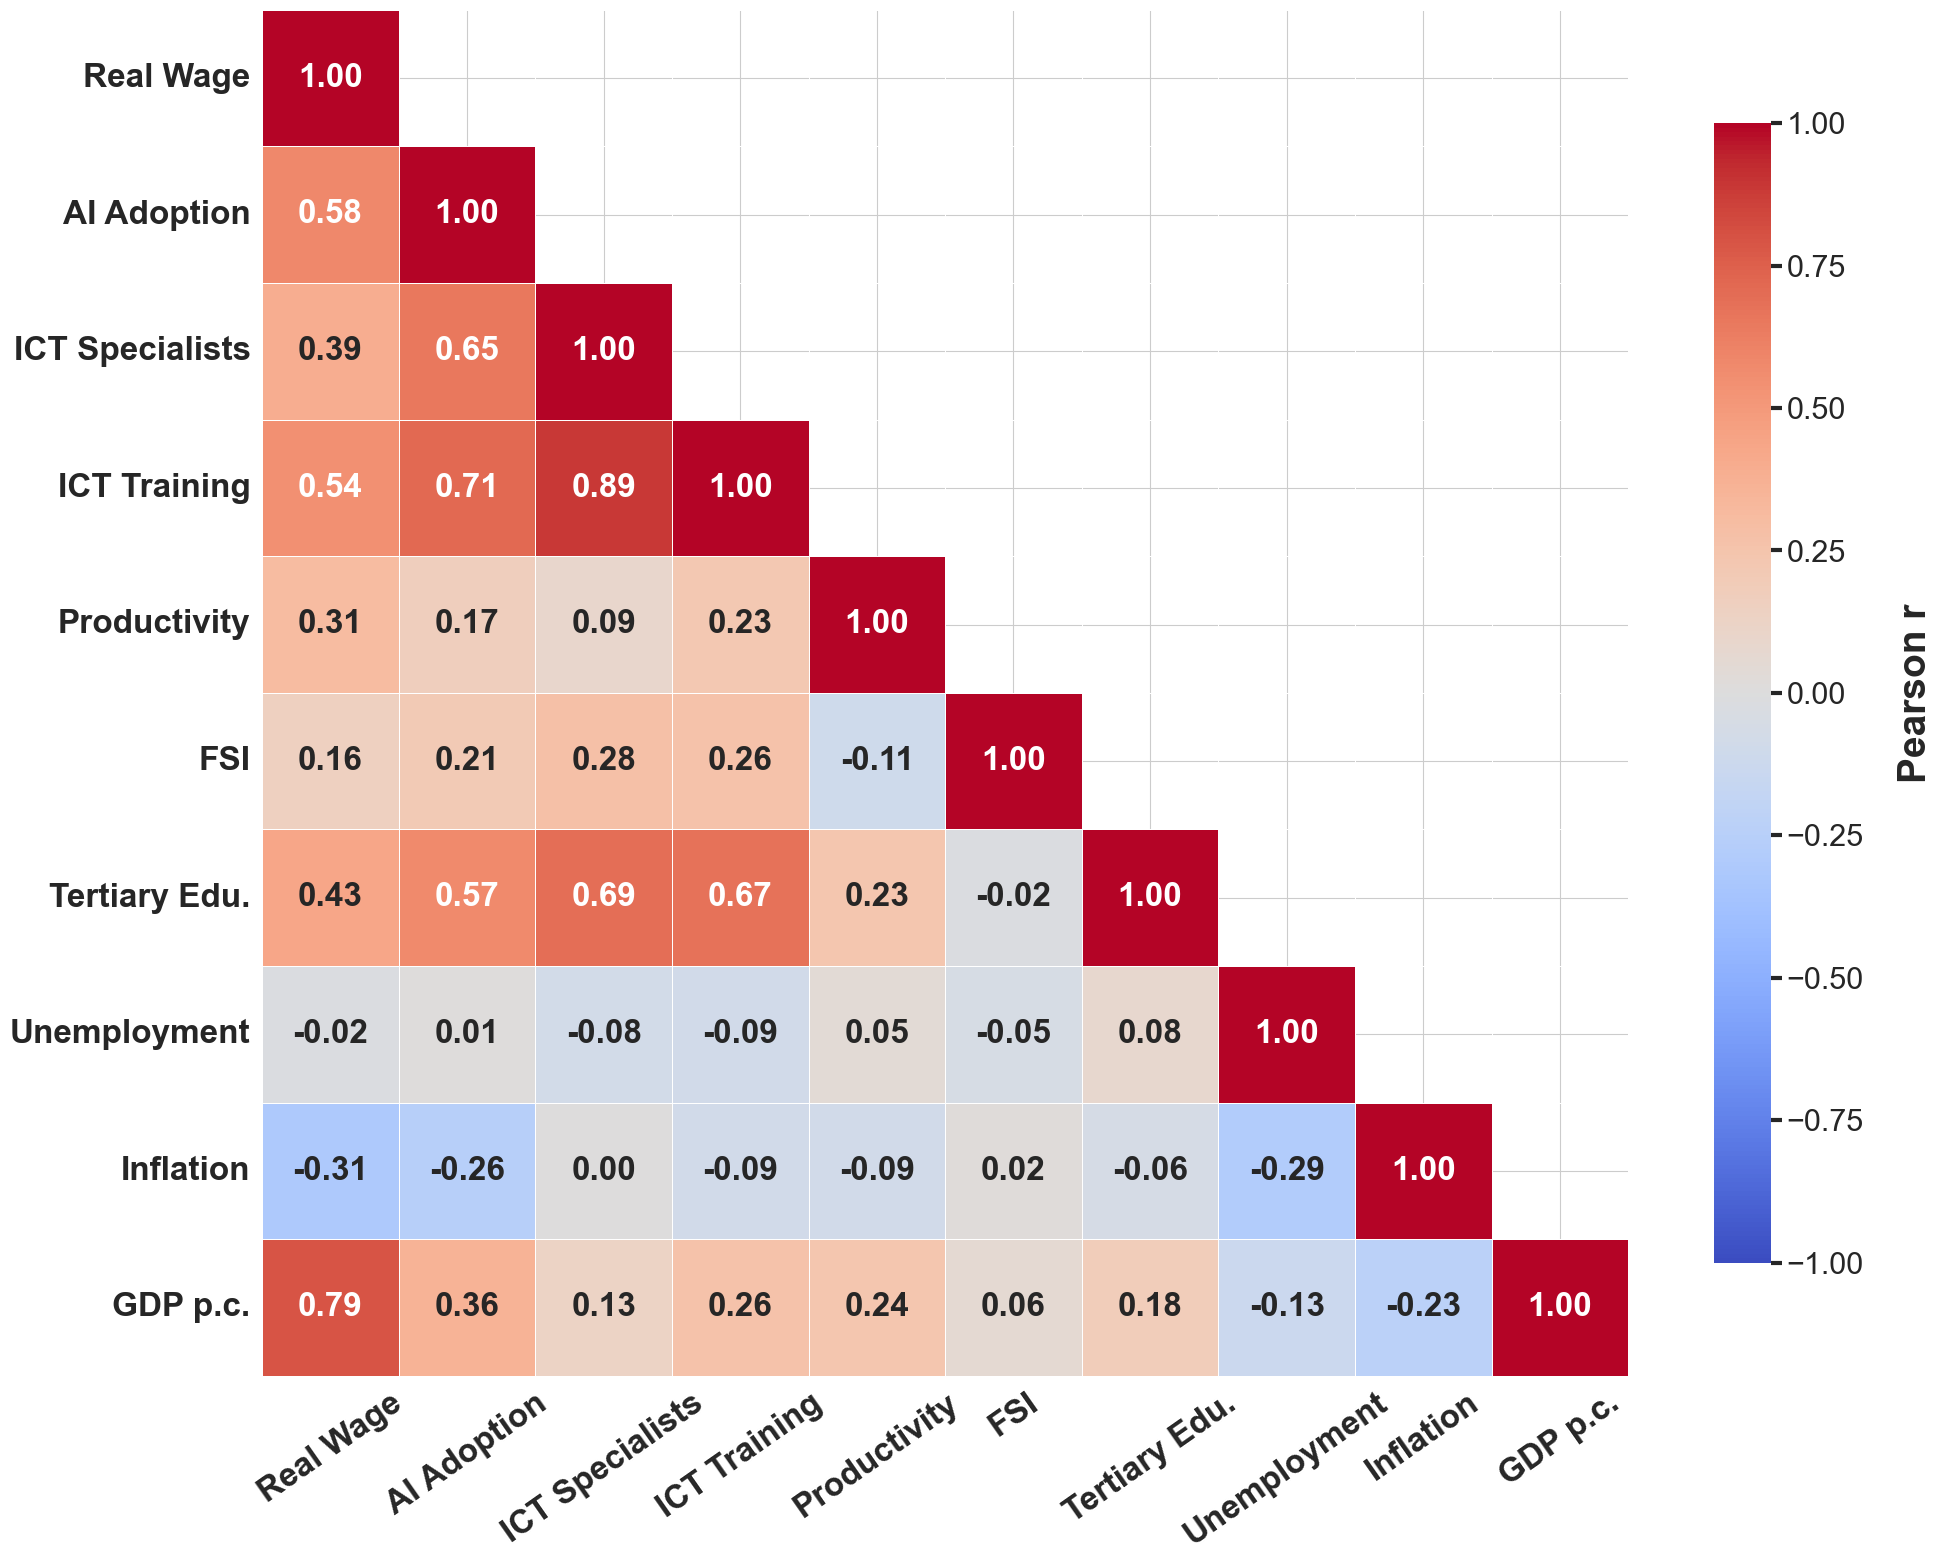

In [ ]:
# Choose variables for the matrix
cols = [
    "real_wage", "ai_adoption", "spec_ict", "training_ict", "productivity", "FSI",
     "tert_edu", "unempl_r", "infl_r", "gdp"
]

corr = data[cols].corr()

# Mask the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Readable variable labels
labels = [
    "Real Wage", "AI Adoption", "ICT Specialists", "ICT Training",
    "Productivity", "FSI", "Tertiary Edu.",
    "Unemployment", "Inflation", "GDP p.c."
]

# Pearson correlation matrix, lower triangle only (upper triangle masked to avoid redundancy)
fig, ax = plt.subplots(figsize=(20, 17))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": THESIS_ANNOT_SIZE_LG, "weight": "bold"},
    cbar_kws={"shrink": 0.75},
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.tick_params(axis='x', labelsize=THESIS_TICK_SIZE_LG, rotation=35)
ax.tick_params(axis='y', labelsize=THESIS_TICK_SIZE_LG, rotation=0)

# Make tick labels extra bold
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight('bold')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=THESIS_TICK_SIZE_LG, width=3, length=8)
cbar.ax.set_ylabel('Pearson r', fontsize=THESIS_LABEL_SIZE_LG, fontweight='bold', labelpad=25)

plt.tight_layout()
plt.show()